In [15]:
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import xarray as xr
from mpl_toolkits.axes_grid1.inset_locator import mark_inset


from acspype import ACSDev
import acspype.processing as acsproc

In [16]:
data_fp = '../../dev_tools/test_files/TEST_SHIMADA_202405.nc'
dev_fp = '../../dev_tools/test_files/ACS-00412_2023-05-10.dev'

In [17]:
acs = xr.open_dataset(data_fp)
acs = acs.drop_vars([v for v in acs.data_vars if '_dark' in v], errors = 'ignore')

dev = ACSDev(dev_fp)

In [18]:
acs['internal_temperature'] = acsproc.compute_internal_temperature(counts = acs.raw_internal_temperature)
acs = acs.drop_vars(['raw_internal_temperature'], errors = 'ignore')

In [19]:
acs['a_uncorr'] = acsproc.compute_uncorrected(signal_counts=acs.a_signal,
                                                   reference_counts=acs.a_reference,
                                                   path_length = dev.path_length)

acs['c_uncorr'] = acsproc.compute_uncorrected(signal_counts = acs.c_signal,
                                                   reference_counts = acs.c_reference,
                                                   path_length = dev.path_length)

acs['a_m_discontinuity'] = acsproc.compute_measured(uncorrected = acs.a_uncorr,
                                                    internal_temperature = acs.internal_temperature,
                                                    offset = dev.a_offset,
                                                    func_delta_t = dev.func_a_delta_t)

acs['c_m_discontinuity'] = acsproc.compute_measured(uncorrected = acs.c_uncorr,
                                                    internal_temperature = acs.internal_temperature,
                                                    offset = dev.c_offset,
                                                    func_delta_t=dev.func_c_delta_t)

discontinuity_index = acsproc.find_discontinuity_index(a_wavelength = acs.a_wavelength,
                                                       c_wavelength = acs.c_wavelength,
                                                       min_wvl = 500, max_wvl = 650)

acs['a_m'], acs['a_discontinuity_offset'] = acsproc.discontinuity_correction(measured = acs.a_m_discontinuity,
                                                                             discontinuity_index=discontinuity_index,
                                                                             wavelength_dim='a_wavelength')

acs['c_m'], acs['c_discontinuity_offset'] = acsproc.discontinuity_correction(measured = acs.c_m_discontinuity,
                                                                             discontinuity_index=discontinuity_index,
                                                                             wavelength_dim='c_wavelength')

In [20]:
s0 = acs.sel(time = datetime(2024,6,4,3,9,56,344460), method = 'nearest')
s1 = acs.sel(time = datetime(2024,6,4,3,31,34,289202), method = 'nearest')
disc_wvl = float(acs.a_wavelength.values[discontinuity_index])

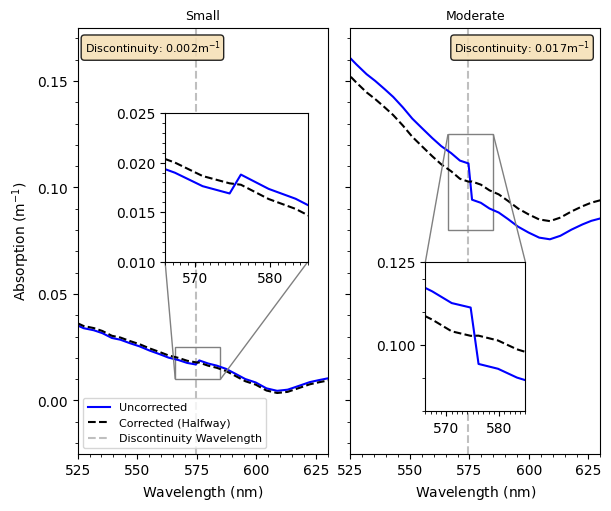

In [21]:
fig, ax = plt.subplots(1,2, figsize = (6,5), constrained_layout = True, sharex = True,sharey = True)


ax[0].set_title('Small', fontsize = 9)
ax[0].plot(s0.a_wavelength, s0.a_m_discontinuity, label = 'Uncorrected', color = 'blue')
ax[0].plot(s0.a_wavelength, s0.a_m, label = 'Corrected (Halfway)', color = 'black', linestyle = '--')
ax[0].axvline(disc_wvl, color = 'black', linestyle = '--', zorder = 0, alpha = 0.25, label = 'Discontinuity Wavelength')


ax[1].set_title('Moderate', fontsize = 9)
ax[1].plot(s1.a_wavelength, s1.a_m_discontinuity, label = 'Discontinuity Uncorrected', color = 'blue')
ax[1].plot(s1.a_wavelength, s1.a_m, label = 'Discontinuity Corrected', color = 'black', linestyle = '--')
ax[1].axvline(disc_wvl, color = 'black', linestyle = '--', zorder = 0, alpha = 0.25,label = 'Discontinuity Location')


ax[-1].set_xlim(525,630)
#ax[-1].set_ylim(-0.05,0.175)
ax[-1].set_ylim(-0.025,0.175)


ax[-1].xaxis.set_major_locator(MultipleLocator(25))
ax[-1].xaxis.set_minor_locator(MultipleLocator(5))
ax[-1].yaxis.set_major_locator(MultipleLocator(0.05))
ax[-1].yaxis.set_minor_locator(MultipleLocator(0.01))


ax[0].set_ylabel(r'Absorption ($\mathrm{m^{-1}}$)')
ax[0].set_xlabel(r'Wavelength ($\mathrm{nm}$)')
ax[1].set_xlabel(r'Wavelength ($\mathrm{nm}$)')

# Text Boxes
props = dict(boxstyle='round', facecolor='wheat', alpha=0.85)
t0 = r"Discontinuity: {}".format(float(np.abs(np.round(s0.a_discontinuity_offset,4)))) + r"$\mathrm{m^{{-1}}}$"
ax[0].text(0.0275, 0.975, t0, transform=ax[0].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)
t1 = r"Discontinuity: {}".format(float(np.abs(np.round(s1.a_discontinuity_offset,3)))) + r"$\mathrm{m^{{-1}}}$"
ax[1].text(0.415, 0.975, t1, transform=ax[1].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)


# Inset ax0
x1,x2,y1,y2 = 566,585,0.01,0.025
axins0 = ax[0].inset_axes([0.35, 0.45, 0.57, 0.35], xlim=(x1, x2), ylim=(y1, y2))
#ax[0].indicate_inset_zoom(axins0, edgecolor="black")

mark_inset(ax[0], axins0, loc1=3, loc2=4, fc="none", ec="0.5") # Connects upper-left of zoom box to lower-right of inset

axins0.plot(s0.a_wavelength, s0.a_m_discontinuity, color = 'blue')
axins0.plot(s0.a_wavelength, s0.a_m, color = 'black', linestyle = '--')
axins0.xaxis.set_major_locator(MultipleLocator(10))
axins0.xaxis.set_minor_locator(MultipleLocator(1))
axins0.yaxis.set_major_locator(MultipleLocator(0.005))
axins0.yaxis.set_minor_locator(MultipleLocator(0.001))


# Inset ax1
x1,x2,y1,y2 = 566,585,0.08,0.125
axins1 = ax[1].inset_axes([0.3, 0.1, 0.4, 0.35], xlim=(x1, x2), ylim=(y1, y2))
#ax[1].indicate_inset_zoom(axins1, edgecolor="black")

mark_inset(ax[1], axins1, loc1=1, loc2=2, fc="none", ec="0.5") # Connects upper-left of zoom box to lower-right of inset

axins1.plot(s1.a_wavelength, s1.a_m_discontinuity, color = 'blue')
axins1.plot(s1.a_wavelength, s1.a_m, color = 'black', linestyle = '--')
axins1.xaxis.set_major_locator(MultipleLocator(10))
axins1.xaxis.set_minor_locator(MultipleLocator(1))
axins1.yaxis.set_major_locator(MultipleLocator(0.025))
axins1.yaxis.set_minor_locator(MultipleLocator(0.01))

ax[0].legend(loc = 'lower left',fontsize = 8)

plt.savefig('figure_1_discontinuity_example.jpg',dpi=1200, format = 'jpg')
plt.savefig('figure_1_discontinuity_example.svg', dpi = 1200, format = 'svg')
